In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv('data_science_job.csv')

In [36]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [37]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [38]:
df.shape

(19158, 13)

In [39]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [40]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
15056,0.939,no_enrollment,Graduate,7.0,7.0
11474,0.887,no_enrollment,Masters,5.0,107.0
7940,0.920,no_enrollment,Graduate,7.0,11.0
11338,0.689,NaN,High School,3.0,99.0
552,0.698,no_enrollment,Graduate,14.0,24.0


In [50]:
df['education_level'].value_counts()

Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: education_level, dtype: int64

In [13]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [41]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

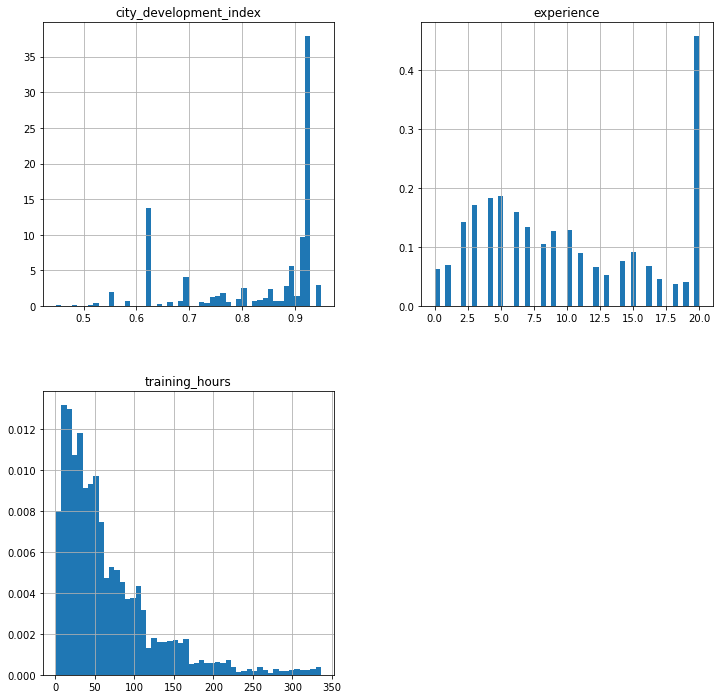

In [42]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

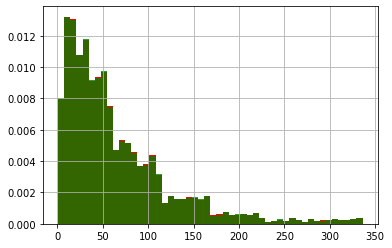

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

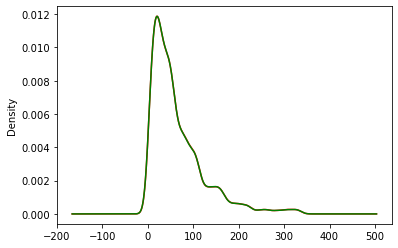

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

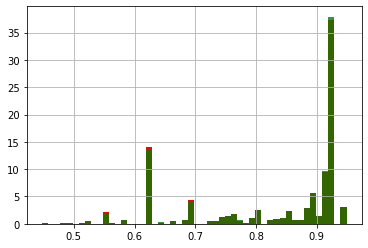

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

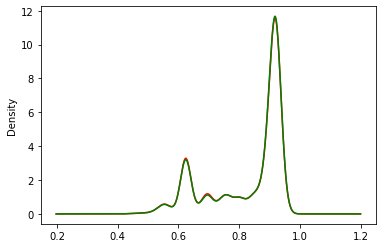

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

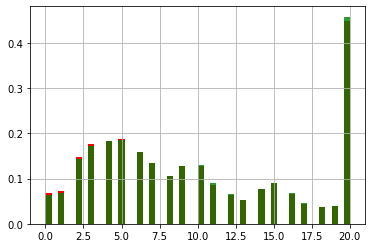

In [47]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

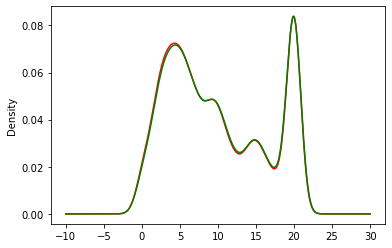

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

In [51]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [52]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


### ***Practicing CCA***

In [32]:
df = pd.read_csv('data_science_job.csv')

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [33]:
[col for col in df.columns if df[col].isnull().sum()==0]

['enrollee_id', 'city', 'relevent_experience', 'target']

In [34]:
no_null_cols = [col for col in df.columns if df[col].isnull().sum()==0] # This gives us all the columns which Do not have any null values

In [35]:
# Now we will drop these columns from our case study 
df.drop(no_null_cols , axis=1 , inplace=True)

In [36]:
df.head()

,city_development_index,gender,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours
0,0.920,Male,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0
1,0.776,Male,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0
2,0.624,NaN,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0
3,0.789,NaN,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0
4,0.767,Male,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0


In [37]:
# Let us look at the total %age of null values in each column

df.isnull().mean()*100

city_development_index     2.500261
gender                    23.530640
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
dtype: float64

- Columns with nulls > 5% are in company size (30.99%), company type(32.04%) and gender(23.53%), major_discipline(14.68%) 
- Rest all columns have nulls < 5% in them


### CCA - complete case analysis requires dropping all the rows which have Nulls in them 
- If we drop all the rows, The number of total rows left will be

In [38]:
print(f"Before Dropping all nulls -> {df.shape}")
df.dropna(how='any').shape

print(f"After Dropping the Nulls -> {df.dropna(how='any').shape}")

Before Dropping all nulls -> (19158, 9)
After Dropping the Nulls -> (8434, 9)


### ***Clearly this is Not the good Idea***

- Let us see by dropping only those Nulls from those columns which have Total Nulls < 5% 

In [39]:
cols = [col for col in df.columns if df[col].isnull().mean() < 0.05 and df[col].isnull().mean()>0]

In [43]:
new_df = df.dropna(subset=cols,how='any')

In [44]:
print(f"Before Dropping -> {df.shape}")
print(f"After Dropping -> {new_df.shape}")

Before Dropping -> (19158, 9)
After Dropping -> (17182, 9)


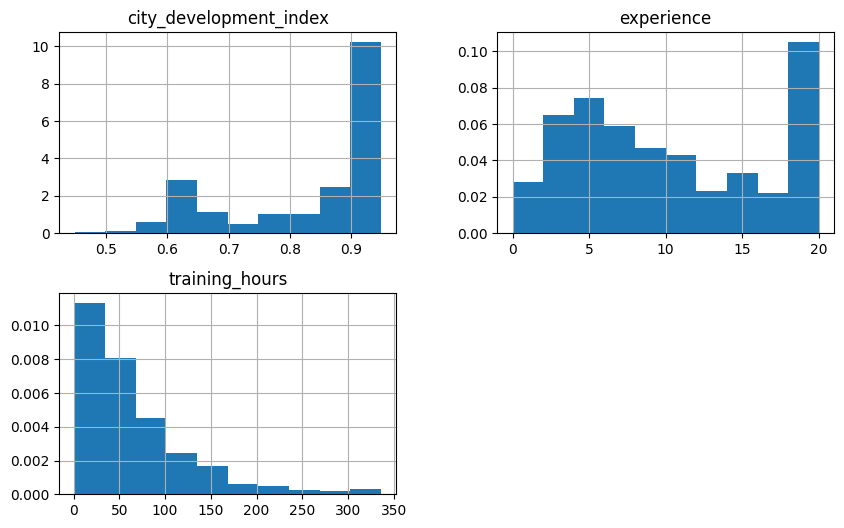

In [55]:
# Let us plot the distribution of the columns which we dropped before dropping and after dropping
df.hist(density=True , figsize=(10,6))
plt.show()

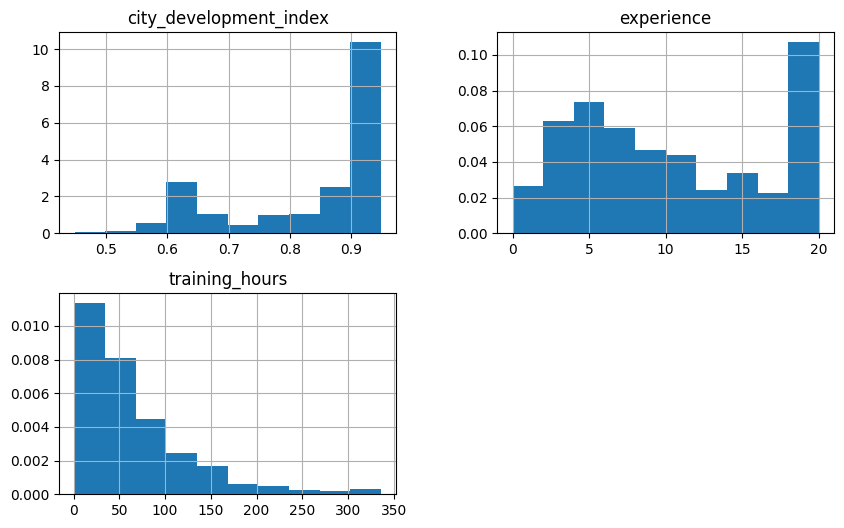

In [52]:
new_df.hist(density=True, figsize=(10,6))
plt.show()

### We see no changes in the distribution after dropping the nulls -> Which is good !!
- If distribution changes, then it is a bad sign ! and dropping is not the good idea anymore 

### ***Comparing PDF of each Numeric column***

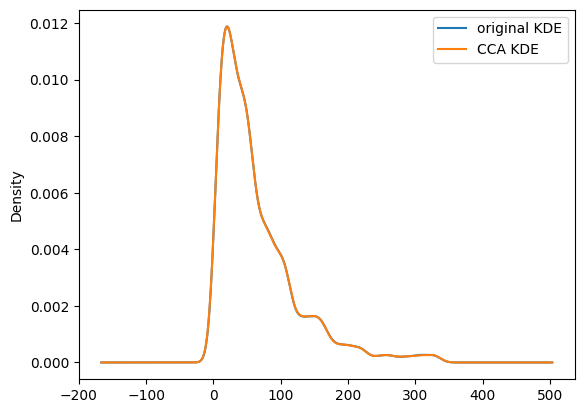

In [67]:
df['training_hours'].plot.density(label='original KDE')
new_df['training_hours'].plot.density(label='CCA KDE')
plt.legend()
plt.show()

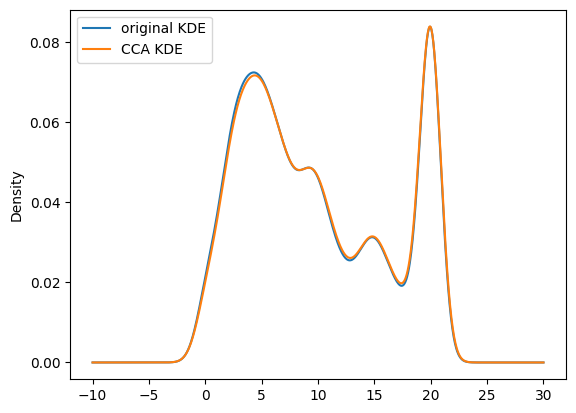

In [68]:
df['experience'].plot.density(label='original KDE')
new_df['experience'].plot.density(label='CCA KDE')
plt.legend()
plt.show()

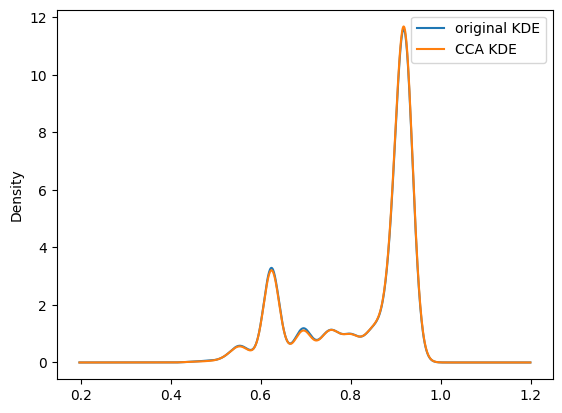

In [69]:
df['city_development_index'].plot.density(label='original KDE')
new_df['city_development_index'].plot.density(label='CCA KDE')
plt.legend()
plt.show()

### We see that the Kernel Density Plots overalaps perfectly -> Thus our CCA can work !!

In [71]:
print(new_df.isnull().mean()*100)

city_development_index     0.000000
gender                    22.541031
enrolled_university        0.000000
education_level            0.000000
major_discipline          12.530555
experience                 0.000000
company_size              29.786986
company_type              30.799674
training_hours             0.000000
dtype: float64


### To deal with Columns having Many Nulls -> We have to use Imputers -> Later!!